# Federated Mutual Learning qua Proxy Model — IDS trên CIC-IoT 2023

Tái hiện phương pháp **Adaptive Federated Mutual Learning** của paper
*"Lightweight Federated Learning for On-Device NILM"* (Li et al.), áp cho bài toán
**IDS phân loại đa lớp (34 lớp)** trên dữ liệu non-IID của **10 client**.

Mỗi client giữ **1 personalized model** (kiến trúc dị biệt) và **1 proxy model**
(kiến trúc thống nhất). Hai model học lẫn nhau qua *mutual distillation*; chỉ **proxy**
được aggregate (FedAvg) trên server, personalized model + data thô ở lại client.

**Ánh xạ so với paper (giữ nguyên công thức toán học):**

- Bỏ phần NAS. Dị biệt hoá personalized model bằng **5 GRU** (client 1–5) + **5 Transformer** (client 6–10).
- **Proxy model** = 1D-CNN (3 conv kernel=5 + 1 dense) — đúng mô tả proxy ở mục IV-A2 của paper.
- Loss cơ sở đổi từ L2 (hồi quy NILM) sang **Cross-Entropy** (phân loại IDS).

| Paper | Công thức | Cài đặt ở đây |
|---|---|---|
| (5) FedAvg | $\min_w \mathcal L(\tilde w)=\frac1K\sum_{k}\mathcal L_{\text{train}}(w_k,x_k)$ | trung bình đều state proxy 10 client |
| (17) | $\mathcal L_{\text{train},s}=\ell_s+\ell_d,\quad \mathcal L_{\text{train},r}=\ell_r+\ell_d$ | tổng `l_s + l_r + l_d`, backward chung |
| (18) | $\ell_s=\ell(y,s),\ \ell_r=\ell(y,r)$ | `CrossEntropy(logits, y)` |
| (19) | $\ell_d=\dfrac{\ell(y_s,y_r)}{\ell_s+\ell_r}$ | `l(y_s,y_r)`=KL đối xứng (T=3); mẫu số detach = trọng số thích nghi |
| Alg.1 | vòng round: cập nhật cả 2 model → upload proxy → FedAvg → distribute | Cell 8 |

Notebook chạy trên **Kaggle GPU T4 ×2**. Tối ưu: tensor thường trú GPU, batch lớn, AMP,
**2 client chạy song song trên 2 GPU** (cân tải theo kích thước dữ liệu).


## Cell 1 — Kiểm tra môi trường

In [12]:
import sys, torch
print("Python:", sys.version.split()[0], "| PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
n_gpu = torch.cuda.device_count()
for i in range(n_gpu):
    print(f"  GPU[{i}]: {torch.cuda.get_device_name(i)}")
assert n_gpu >= 1, "Cần ít nhất 1 GPU. Đặt accelerator 'GPU T4 x2' trong Kaggle settings."
if n_gpu != 2:
    print(f"[cảnh báo] Mong đợi 2 GPU (T4 x2), đang thấy {n_gpu}. Sẽ tự điều chỉnh việc song song hoá.")
torch.backends.cudnn.benchmark = True   # autotune cho shape cố định (batch drop_last)

Python: 3.12.13 | PyTorch: 2.10.0+cu128
CUDA available: True
  GPU[0]: Tesla T4
  GPU[1]: Tesla T4


## Cell 2 — Import + CONFIG (mọi path & siêu tham số ở đây)

In [13]:
from pathlib import Path
import numpy as np, pandas as pd
import torch, torch.nn as nn, torch.nn.functional as F

CONFIG = {
    # --- paths (Kaggle) ---
    "input_dir":   "/kaggle/input/datasets/odixe0502/data-for-10clients",
    "run_name":    "proxy_fml_ids",
    "n_clients":   10,
    "num_classes": 34,
    "label_col":   "Label",

    # --- kiến trúc ---
    "embed_dim":   64,          # d — feature tokenizer (dùng luôn làm d_model của Transformer)
    "gru_hidden":  128,
    "gru_layers":  1,
    "tf_heads":    4,
    "tf_layers":   2,
    "tf_ff":       128,
    "tf_dropout":  0.1,
    "proxy_ch":    [32, 64, 64],  # 3 lớp conv1d
    "proxy_k":     5,             # kernel size (giống paper)

    # --- federated / training ---
    "rounds":          10,      # R
    "local_epochs":    1,       # E
    "batch_size":      8192,
    "lr":              1e-3,
    "weight_decay":    1e-5,
    "kd_temp":         3.0,     # T — nhiệt độ distillation
    "finetune_epochs": 2,       # fine-tune personalized cuối (paper Step 4); 0 = tắt

    # --- mất cân bằng lớp ---
    "class_weighted":    True,  # CE có trọng số lớp (nghịch đảo tần suất) -> nâng macro-F1/recall
    "class_weight_clip": 20.0,  # chặn trên trọng số lớp hiếm để tránh gradient nổ

    # --- hệ thống ---
    "local_test_frac": 0.2,     # tách local-test trong mỗi client (stratified)
    "parallel_2gpu":   True,    # chạy 2 nhóm client song song trên 2 GPU
    "eval_batch":      8192,    # batch khi inference/đánh giá (GRU/Transformer 25 token -> để nhỏ tránh OOM)
    "seed":            42,
}
torch.manual_seed(CONFIG["seed"]); np.random.seed(CONFIG["seed"])

# gán model cho từng client: 1..5 = GRU, 6..10 = Transformer
CLIENT_MODEL = {k: ("gru" if k <= 5 else "transformer")
                for k in range(1, CONFIG["n_clients"] + 1)}

OUT = Path("/kaggle/working") / CONFIG["run_name"]
for sub in ("checkpoints", "metrics", "artifacts", "logs"):
    (OUT / sub).mkdir(parents=True, exist_ok=True)
print("Output ->", OUT)
print("client -> model:", CLIENT_MODEL)

Output -> /kaggle/working/proxy_fml_ids
client -> model: {1: 'gru', 2: 'gru', 3: 'gru', 4: 'gru', 5: 'gru', 6: 'transformer', 7: 'transformer', 8: 'transformer', 9: 'transformer', 10: 'transformer'}


## Cell 3 — Nạp label mapping, xác định cột đặc trưng, helper đọc dữ liệu

Dữ liệu đã được chuẩn hoá sẵn (QuantileTransformer) ở bước tiền xử lý → **không scale lại**.
`to_xy` tự xử lý cả trường hợp cột `Label` đã là số 0–33 hoặc còn là chuỗi tên lớp.

In [14]:
INP = Path(CONFIG["input_dir"])

# --- label mapping: id (0..33) <-> tên lớp ---
map_df = pd.read_csv(INP / "label_mapping.csv")
print("label_mapping.csv columns:", list(map_df.columns))
_cols = list(map_df.columns)
_num = [c for c in _cols if map_df[c].dtype.kind in "iuf"]
id_col   = _num[0] if _num else _cols[-1]
name_col = [c for c in _cols if c != id_col][0]
id2name = {int(i): str(n) for i, n in zip(map_df[id_col], map_df[name_col])}
name2id = {v: k for k, v in id2name.items()}
CLASS_NAMES = [id2name.get(i, str(i)) for i in range(CONFIG["num_classes"])]
print("Ví dụ mapping:", dict(list(id2name.items())[:5]))

# --- cột đặc trưng (đọc thử vài dòng của client 1) ---
_peek = pd.read_csv(INP / "client_1_train.csv", nrows=5)
_peek = _peek.loc[:, ~_peek.columns.str.startswith("Unnamed")]
FEATURES = [c for c in _peek.columns if c != CONFIG["label_col"]]
CONFIG["n_features"] = len(FEATURES)
print(f"#features = {len(FEATURES)}")
print("features:", FEATURES)

FEAT_DTYPE = {f: np.float32 for f in FEATURES}

def load_csv(path):
    df = pd.read_csv(path, dtype=FEAT_DTYPE)
    return df.loc[:, ~df.columns.str.startswith("Unnamed")]

def to_xy(df):
    X = df[FEATURES].to_numpy(dtype=np.float32)
    lab = df[CONFIG["label_col"]]
    if lab.dtype.kind in "iu":
        y = lab.to_numpy(dtype=np.int64)
    else:
        y = lab.map(name2id).to_numpy(dtype=np.int64)
    return X, y

label_mapping.csv columns: ['Encoded_ID', 'Label_Name']
Ví dụ mapping: {0: 'BACKDOOR_MALWARE', 1: 'BENIGN', 2: 'BROWSERHIJACKING', 3: 'COMMANDINJECTION', 4: 'DDOS-ACK_FRAGMENTATION'}
#features = 25
features: ['ack_flag_number', 'AVG', 'Std', 'UDP', 'fin_count', 'Max', 'TCP', 'syn_count', 'Protocol Type', 'Rate', 'IAT', 'syn_flag_number', 'rst_flag_number', 'Tot sum', 'HTTPS', 'ack_count', 'fin_flag_number', 'HTTP', 'rst_count', 'Header_Length', 'psh_flag_number', 'ICMP', 'Time_To_Live', 'ARP', 'DNS']


## Cell 4 — Tách local train/test, đưa tensor thường trú lên GPU, cân tải 2 GPU

- Mỗi client tách **local-test 20% (stratified)** — dùng để đánh giá personalized model của chính client đó.
- Toàn bộ tensor client được **nạp thẳng lên GPU một lần** (bỏ DataLoader) → cắt minibatch bằng chỉ số ngay trên GPU.
- **Cân tải**: gán client cho 2 GPU sao cho tổng số mẫu train trên mỗi GPU xấp xỉ nhau (greedy).

In [15]:
def stratified_split(y, test_frac, seed):
    # Tách train/test giữ tỉ lệ lớp; lớp hiếm được ưu tiên giữ ở train (chừa >=1 mẫu train).
    rng = np.random.default_rng(seed)
    tr_idx, te_idx = [], []
    for c in np.unique(y):
        idx = np.where(y == c)[0]; rng.shuffle(idx)
        n_test = int(np.floor(len(idx) * test_frac))
        n_test = min(n_test, max(0, len(idx) - 1))   # luôn chừa >=1 cho train
        te_idx.append(idx[:n_test]); tr_idx.append(idx[n_test:])
    return np.concatenate(tr_idx), np.concatenate(te_idx)

# --- gán device cho từng client (cân tải) ---
use_parallel = CONFIG["parallel_2gpu"] and torch.cuda.device_count() >= 2
CLIENT_DEVICE = {}
_sizes = {}
for k in range(1, CONFIG["n_clients"] + 1):
    _sizes[k] = sum(1 for _ in open(INP / f"client_{k}_train.csv")) - 1   # đếm dòng nhanh
if use_parallel:
    _load = [0, 0]
    for k in sorted(_sizes, key=lambda x: -_sizes[x]):
        g = 0 if _load[0] <= _load[1] else 1
        CLIENT_DEVICE[k] = f"cuda:{g}"; _load[g] += _sizes[k]
    print(f"Cân tải 2 GPU: GPU0={_load[0]:,} mẫu | GPU1={_load[1]:,} mẫu")
else:
    CLIENT_DEVICE = {k: "cuda:0" for k in _sizes}
    print("Chạy tuần tự trên cuda:0")
gpu_clients = {0: [k for k in CLIENT_DEVICE if CLIENT_DEVICE[k] == "cuda:0"],
               1: [k for k in CLIENT_DEVICE if CLIENT_DEVICE[k] == "cuda:1"]}
print("client -> device:", CLIENT_DEVICE)

# --- nạp dữ liệu client -> tensor GPU ---
client_data = {}
for k in range(1, CONFIG["n_clients"] + 1):
    df = load_csv(INP / f"client_{k}_train.csv")
    X, y = to_xy(df); del df
    tr, te = stratified_split(y, CONFIG["local_test_frac"], CONFIG["seed"] + k)
    dev = CLIENT_DEVICE[k]
    client_data[k] = {
        "Xtr": torch.tensor(X[tr], device=dev), "ytr": torch.tensor(y[tr], device=dev),
        "Xte": torch.tensor(X[te], device=dev), "yte": torch.tensor(y[te], device=dev),
        "device": dev,
    }
    print(f"client {k:2d} [{CLIENT_MODEL[k]:11s}] {dev}: train={len(tr):>9,} test={len(te):>8,} "
          f"| #classes={len(np.unique(y))}")
    del X, y

# --- global test (đánh giá proxy toàn cục) đặt trên cuda:0 ---
_g = load_csv(INP / "global_test_data.csv")
Xg, yg = to_xy(_g); del _g
GLOBAL_TEST = {"X": torch.tensor(Xg, device="cuda:0"), "y": torch.tensor(yg, device="cuda:0")}
print(f"global_test: {len(yg):,} mẫu | #classes={len(np.unique(yg))}")
del Xg, yg

Cân tải 2 GPU: GPU0=17,243,164 mẫu | GPU1=18,771,430 mẫu
client -> device: {8: 'cuda:0', 9: 'cuda:1', 10: 'cuda:1', 3: 'cuda:1', 6: 'cuda:1', 5: 'cuda:0', 2: 'cuda:1', 4: 'cuda:0', 7: 'cuda:1', 1: 'cuda:0'}
client  1 [gru        ] cuda:0: train=   25,219 test=   6,301 | #classes=8
client  2 [gru        ] cuda:1: train=1,769,282 test= 442,307 | #classes=21
client  3 [gru        ] cuda:1: train=2,982,772 test= 745,678 | #classes=25
client  4 [gru        ] cuda:0: train=1,536,207 test= 384,047 | #classes=8
client  5 [gru        ] cuda:0: train=2,025,511 test= 506,370 | #classes=14
client  6 [transformer] cuda:1: train=2,149,295 test= 537,322 | #classes=5
client  7 [transformer] cuda:1: train=1,459,983 test= 364,992 | #classes=11
client  8 [transformer] cuda:0: train=10,207,618 test=2,551,891 | #classes=28
client  9 [transformer] cuda:1: train=3,483,360 test= 870,832 | #classes=19
client 10 [transformer] cuda:1: train=3,172,491 test= 793,116 | #classes=14
global_test: 9,003,649 mẫu | #clas

## Cell 5 — Định nghĩa mô hình

- **FeatureTokenizer** (kiểu FT-Transformer): mỗi đặc trưng vô hướng → 1 token `d` chiều → chuỗi 25 token.
- **GRUModel** / **TransformerModel**: personalized model dị biệt (client 1–5 / 6–10).
- **ProxyCNN**: proxy thống nhất — 3 conv1d kernel=5 + 1 dense (giống paper).

Tất cả cùng xuất logits trên **34 lớp toàn cục** để FedAvg proxy và distillation khớp chiều.

In [ ]:
class FeatureTokenizer(nn.Module):
    # Mỗi đặc trưng vô hướng x_i -> token: x_i * W_i + b_i  (W_i, b_i in R^d).
    def __init__(self, n_features, d):
        super().__init__()
        self.weight = nn.Parameter(torch.empty(n_features, d))
        self.bias   = nn.Parameter(torch.empty(n_features, d))
        nn.init.normal_(self.weight, std=0.02); nn.init.zeros_(self.bias)
    def forward(self, x):                       # x: [B, F]
        return x.unsqueeze(-1) * self.weight + self.bias   # [B, F, d]

class GRUModel(nn.Module):      
    def __init__(self, cfg):
        super().__init__()
        d = cfg["embed_dim"]
        self.tok = FeatureTokenizer(cfg["n_features"], d)
        self.gru = nn.GRU(d, cfg["gru_hidden"], cfg["gru_layers"],
                          batch_first=True, bidirectional=True)
        self.head = nn.Linear(cfg["gru_hidden"] * 2, cfg["num_classes"])
    def forward(self, x):
        out, _ = self.gru(self.tok(x))          # [B, F, 2H]
        return self.head(out.mean(dim=1))       # mean-pool theo token (thứ tự feature không mang nghĩa)

class TransformerModel(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        d = cfg["embed_dim"]
        self.tok = FeatureTokenizer(cfg["n_features"], d)
        self.cls = nn.Parameter(torch.zeros(1, 1, d))
        layer = nn.TransformerEncoderLayer(d_model=d, nhead=cfg["tf_heads"],
                    dim_feedforward=cfg["tf_ff"], dropout=cfg["tf_dropout"],
                    batch_first=True, activation="gelu")
        self.encoder = nn.TransformerEncoder(layer, cfg["tf_layers"])
        self.head = nn.Linear(d, cfg["num_classes"])
    def forward(self, x):
        t = self.tok(x)                          # [B, F, d]
        cls = self.cls.expand(t.size(0), -1, -1) # [B, 1, d]
        z = self.encoder(torch.cat([cls, t], dim=1))
        return self.head(z[:, 0])                # token CLS

class ProxyCNN(nn.Module):
    # Proxy thống nhất (paper IV-A2): 3 conv1d kernel=5 + 1 dense. 25 đặc trưng = tín hiệu 1D.
    def __init__(self, cfg):
        super().__init__()
        ch, k = cfg["proxy_ch"], cfg["proxy_k"]; pad = k // 2
        self.net = nn.Sequential(
            nn.Conv1d(1, ch[0], k, padding=pad),      nn.BatchNorm1d(ch[0]), nn.ReLU(),
            nn.Conv1d(ch[0], ch[1], k, padding=pad),  nn.BatchNorm1d(ch[1]), nn.ReLU(),
            nn.Conv1d(ch[1], ch[2], k, padding=pad),  nn.BatchNorm1d(ch[2]), nn.ReLU(),
            nn.AdaptiveAvgPool1d(1),
        )
        self.head = nn.Linear(ch[2], cfg["num_classes"])
    def forward(self, x):                        # x: [B, F]
        return self.head(self.net(x.unsqueeze(1)).squeeze(-1))

def build_personalized(model_type, cfg):
    return GRUModel(cfg) if model_type == "gru" else TransformerModel(cfg)

def build_proxy(cfg):
    return ProxyCNN(cfg)

# in số tham số
for name, m in [("GRU", GRUModel(CONFIG)), ("Transformer", TransformerModel(CONFIG)),
                ("ProxyCNN", ProxyCNN(CONFIG))]:
    print(f"{name:12s}: {sum(p.numel() for p in m.parameters()):,} params")

GRU         : 160,930 params
Transformer : 72,418 params
ProxyCNN    : 33,570 params


## Cell 6 — Hàm loss (giữ nguyên công thức (17)(18)(19))

- **(18)** label loss = CrossEntropy **có trọng số lớp**: `l_s = CE(z_s, y)`, `l_r = CE(z_r, y)`.
  Trọng số = nghịch đảo tần suất lớp (tính trên toàn bộ dữ liệu train của 10 client), chuẩn hoá về
  trung bình 1 và chặn trên — bù mất cân bằng nặng (34 lớp), nâng macro-F1/recall cho lớp hiếm.
  Tắt bằng `CONFIG["class_weighted"]=False`.
- `l(y_s, y_r)` (thay cho L2 của paper) = **KL đối xứng** trên softmax nhiệt độ T (Deep Mutual Learning):
  $\ell(y_s,y_r)=\mathrm{KL}(p_r\|p_s)+\mathrm{KL}(p_s\|p_r)$, nhân $T^2$ theo chuẩn KD.
- **(19)** distillation thích nghi: $\ell_d=\dfrac{\ell(y_s,y_r)}{\ell_s+\ell_r}$.
  Mẫu số **detach** → là trọng số thích nghi (làm yếu KD khi cả hai model còn kém), tránh việc
  tối ưu "gian lận" bằng cách làm tăng $\ell_s+\ell_r$.

In [17]:
# Trọng số lớp (nghịch đảo tần suất, tính từ dữ liệu train của mọi client)
if CONFIG["class_weighted"]:
    _cnt = torch.zeros(CONFIG["num_classes"])
    for k in client_data:
        _cnt += torch.bincount(client_data[k]["ytr"].cpu(),
                               minlength=CONFIG["num_classes"]).float()
    _w = _cnt.sum() / (_cnt.clamp(min=1) * CONFIG["num_classes"])   # nghịch đảo tần suất
    CLASS_W = (_w / _w.mean()).clamp(max=CONFIG["class_weight_clip"])  # chuẩn hoá + chặn trên
    print(f"class weights: min={CLASS_W.min():.3f} mean={CLASS_W.mean():.3f} max={CLASS_W.max():.3f}")
else:
    CLASS_W = None

def label_loss(logits, y):                    # (18)
    w = None if CLASS_W is None else CLASS_W.to(logits.device)
    return F.cross_entropy(logits, y, weight=w)

def kd_symmetric(z_s, z_r, T):                # l(y_s, y_r): KL đối xứng
    log_ps = F.log_softmax(z_s / T, dim=1)
    log_pr = F.log_softmax(z_r / T, dim=1)
    ps, pr = log_ps.exp(), log_pr.exp()
    kl_r_s = F.kl_div(log_ps, pr, reduction="batchmean")   # KL(p_r || p_s)
    kl_s_r = F.kl_div(log_pr, ps, reduction="batchmean")   # KL(p_s || p_r)
    return (kl_r_s + kl_s_r) * (T * T)

def adaptive_distill(z_s, z_r, l_s, l_r, T, eps=1e-8):     # (19)
    num = kd_symmetric(z_s, z_r, T)
    denom = (l_s + l_r).detach() + eps         # trọng số thích nghi (detach)
    return num / denom

class weights: min=0.002 mean=1.000 max=10.512


## Cell 7 — Train local 1 client (mutual learning) + FedAvg

`train_local` cập nhật **đồng thời** personalized (s) và proxy (r) bằng backward chung
`total = l_s + l_r + l_d` → hiện thực đúng (17): s nhận grad từ `l_s + l_d`, r nhận từ `l_r + l_d`.
Personalized model **tồn tại xuyên suốt các round** (không aggregate); proxy được nạp lại từ bản
toàn cục ở đầu mỗi round. `fedavg` = trung bình đều (1/K) theo (5)/Algorithm 1.

In [18]:
def minibatches(n, bs, device, seed):
    g = torch.Generator(); g.manual_seed(seed)
    perm = torch.randperm(n, generator=g).to(device)
    if n < bs:
        yield perm; return
    for i in range(0, n - bs + 1, bs):        # drop_last -> shape cố định
        yield perm[i:i + bs]

def train_local(k, proxy_state, cfg, round_idx):
    dev = client_data[k]["device"]; torch.cuda.set_device(dev)
    Xtr, ytr = client_data[k]["Xtr"], client_data[k]["ytr"]; n = Xtr.size(0)

    proxy = build_proxy(cfg).to(dev); proxy.load_state_dict(proxy_state)  # Distribute
    pers  = PERSONALIZED[k]                                               # persist local
    opt_p = torch.optim.Adam(pers.parameters(),  lr=cfg["lr"], weight_decay=cfg["weight_decay"])
    opt_r = torch.optim.Adam(proxy.parameters(), lr=cfg["lr"], weight_decay=cfg["weight_decay"])
    scaler = torch.amp.GradScaler("cuda"); T = cfg["kd_temp"]

    pers.train(); proxy.train()
    run = torch.zeros(4, device=dev); nb = 0     # tích luỹ [l_s, l_r, l_d, total] cho loss curve
    for ep in range(cfg["local_epochs"]):
        seed = cfg["seed"] + round_idx * 100000 + k * 100 + ep
        for idx in minibatches(n, cfg["batch_size"], dev, seed):
            xb, yb = Xtr[idx], ytr[idx]
            opt_p.zero_grad(set_to_none=True); opt_r.zero_grad(set_to_none=True)
            with torch.amp.autocast("cuda"):
                z_s = pers(xb)                        # personalized (s)
                z_r = proxy(xb)                       # proxy (r)
                l_s = label_loss(z_s, yb)             # (18)
                l_r = label_loss(z_r, yb)             # (18)
                l_d = adaptive_distill(z_s, z_r, l_s, l_r, T)   # (19)
                total = l_s + l_r + l_d               # (17) cho cả hai model
            scaler.scale(total).backward()
            scaler.step(opt_p); scaler.step(opt_r); scaler.update()
            run += torch.stack([l_s.detach(), l_r.detach(), l_d.detach(), total.detach()]); nb += 1

    m = (run / max(1, nb)).tolist()               # 1 lần sync
    stats = {"l_s": m[0], "l_r": m[1], "l_d": m[2], "total": m[3]}
    return {kk: v.detach().float().cpu() for kk, v in proxy.state_dict().items()}, n, stats

def fedavg(states):
    # w_tilde = (1/K) * sum_k w_k  — công thức (5), trung bình đều (Algorithm 1).
    avg = {}
    for key in states[0]:
        if states[0][key].dtype.is_floating_point:
            avg[key] = torch.stack([s[key] for s in states], 0).mean(0)
        else:                                   # vd num_batches_tracked
            avg[key] = states[0][key].clone()
    return avg

## Cell 8 — Vòng lặp Federated (Algorithm 1)

Mỗi round: distribute proxy toàn cục → train local 2 nhóm client **song song trên 2 GPU** →
upload → FedAvg → đánh giá nhanh proxy trên global test → checkpoint. `PERSONALIZED` giữ 10
personalized model xuyên suốt.

In [19]:
import time
from concurrent.futures import ThreadPoolExecutor

# khởi tạo 10 personalized model (persist) trên đúng device
PERSONALIZED = {}
for k in range(1, CONFIG["n_clients"] + 1):
    PERSONALIZED[k] = build_personalized(CLIENT_MODEL[k], CONFIG).to(CLIENT_DEVICE[k])

@torch.no_grad()
def quick_eval_proxy(state, bs=None):
    # trả (accuracy, CE loss) của proxy toàn cục trên global test -> vẽ accuracy/loss curve
    bs = bs or CONFIG["eval_batch"]
    torch.cuda.set_device("cuda:0")
    m = build_proxy(CONFIG).to("cuda:0")
    m.load_state_dict({kk: v.to("cuda:0") for kk, v in state.items()}); m.eval()
    X, y = GLOBAL_TEST["X"], GLOBAL_TEST["y"]; correct = 0; loss_sum = 0.0
    for i in range(0, X.size(0), bs):
        with torch.amp.autocast("cuda"):
            logits = m(X[i:i+bs]); yb = y[i:i+bs]
            correct += (logits.argmax(1) == yb).sum().item()
            loss_sum += F.cross_entropy(logits.float(), yb, reduction="sum").item()
    n = X.size(0)
    return correct / n, loss_sum / n

# proxy toàn cục khởi tạo
global_state = {kk: v.detach().float().cpu() for kk, v in build_proxy(CONFIG).state_dict().items()}

history = []
for r in range(CONFIG["rounds"]):
    t0 = time.time()

    def run_group(gid, gstate=global_state, rr=r):
        out = {}
        for k in gpu_clients[gid]:
            dev = CLIENT_DEVICE[k]
            pstate = {kk: v.to(dev) for kk, v in gstate.items()}   # Distribute
            out[k] = train_local(k, pstate, CONFIG, rr)
        return out

    results = {}
    if use_parallel:
        with ThreadPoolExecutor(max_workers=2) as ex:
            for f in [ex.submit(run_group, g) for g in (0, 1)]:
                results.update(f.result())
    else:
        results.update(run_group(0))

    # Upload + Aggregate (FedAvg)
    ks = sorted(results)
    global_state = fedavg([results[k][0] for k in ks])

    # loss train trung bình theo số mẫu (cho loss curve)
    ns = np.array([results[k][1] for k in ks], dtype=float); wsum = ns.sum()
    def wmean(key):
        return float((np.array([results[k][2][key] for k in ks]) * ns).sum() / wsum)
    tr_l = {key: wmean(key) for key in ("l_s", "l_r", "l_d", "total")}

    acc, ploss = quick_eval_proxy(global_state); dt = time.time() - t0
    print(f"[round {r+1:02d}/{CONFIG['rounds']}] proxy global-test acc={acc:.4f} loss={ploss:.4f} "
          f"| train total={tr_l['total']:.3f} l_s={tr_l['l_s']:.3f} l_r={tr_l['l_r']:.3f} l_d={tr_l['l_d']:.4f} "
          f"({dt:.1f}s)")
    history.append({"round": r + 1, "proxy_global_acc": float(acc), "proxy_global_loss": float(ploss),
                    "train_total": tr_l["total"], "train_l_s": tr_l["l_s"],
                    "train_l_r": tr_l["l_r"], "train_l_d": tr_l["l_d"], "sec": round(dt, 1)})
    torch.save(global_state, OUT / "checkpoints" / "proxy_last.pt")

torch.save(global_state, OUT / "checkpoints" / "proxy_global.pt")
print("Xong federated. Proxy toàn cục đã lưu.")

[round 01/10] proxy global-test acc=0.4558 loss=3.2142 | train total=2.169 l_s=0.996 l_r=1.085 l_d=0.0877 (174.3s)
[round 02/10] proxy global-test acc=0.5196 loss=2.6691 | train total=1.715 l_s=0.719 l_r=0.903 l_d=0.0930 (184.7s)
[round 03/10] proxy global-test acc=0.5397 loss=2.1430 | train total=1.566 l_s=0.672 l_r=0.807 l_d=0.0876 (185.7s)
[round 04/10] proxy global-test acc=0.5468 loss=1.8627 | train total=1.492 l_s=0.647 l_r=0.759 l_d=0.0862 (186.0s)
[round 05/10] proxy global-test acc=0.5566 loss=1.6752 | train total=1.449 l_s=0.630 l_r=0.733 l_d=0.0861 (185.7s)
[round 06/10] proxy global-test acc=0.5645 loss=1.5878 | train total=1.423 l_s=0.619 l_r=0.718 l_d=0.0867 (185.7s)
[round 07/10] proxy global-test acc=0.5682 loss=1.5039 | train total=1.401 l_s=0.610 l_r=0.704 l_d=0.0869 (185.4s)
[round 08/10] proxy global-test acc=0.5699 loss=1.4587 | train total=1.385 l_s=0.602 l_r=0.695 l_d=0.0870 (185.2s)
[round 09/10] proxy global-test acc=0.5710 loss=1.3924 | train total=1.371 l_s=0

## Cell 9 — Fine-tune personalized cuối (paper Step 4)

Sau federated, mỗi client fine-tune personalized model bằng **chỉ label loss** trên dữ liệu local
để tái chuyên biệt hoá theo phân phối riêng. Vẫn chạy song song 2 GPU.

In [20]:
def finetune_personalized(k, cfg):
    dev = client_data[k]["device"]; torch.cuda.set_device(dev)
    Xtr, ytr = client_data[k]["Xtr"], client_data[k]["ytr"]; n = Xtr.size(0)
    m = PERSONALIZED[k]; m.train()
    opt = torch.optim.Adam(m.parameters(), lr=cfg["lr"], weight_decay=cfg["weight_decay"])
    scaler = torch.amp.GradScaler("cuda")
    for ep in range(cfg["finetune_epochs"]):
        for idx in minibatches(n, cfg["batch_size"], dev, cfg["seed"] + 999000 + k * 100 + ep):
            xb, yb = Xtr[idx], ytr[idx]
            opt.zero_grad(set_to_none=True)
            with torch.amp.autocast("cuda"):
                loss = label_loss(m(xb), yb)
            scaler.scale(loss).backward(); scaler.step(opt); scaler.update()

if CONFIG["finetune_epochs"] > 0:
    def ft_group(gid):
        for k in gpu_clients[gid]:
            finetune_personalized(k, CONFIG)
    if use_parallel:
        with ThreadPoolExecutor(max_workers=2) as ex:
            [f.result() for f in [ex.submit(ft_group, g) for g in (0, 1)]]
    else:
        ft_group(0)
    print(f"Hoàn tất fine-tune personalized ({CONFIG['finetune_epochs']} epoch).")
else:
    print("Bỏ qua fine-tune (finetune_epochs=0).")

Hoàn tất fine-tune personalized (2 epoch).


## Cell 10 — Đánh giá & lưu artifacts

- **Global proxy** → đánh giá trên **global test** (acc, macro-F1, weighted-F1, report, confusion matrix).
- **Mỗi personalized model** → đánh giá trên **local-test của chính client đó**.
- Lưu proxy toàn cục + 10 personalized model + toàn bộ metrics.

In [21]:
import json
from sklearn.metrics import (classification_report, confusion_matrix, accuracy_score,
                             precision_score, recall_score, f1_score)

@torch.no_grad()
def predict(model, X, bs=None):
    bs = bs or CONFIG["eval_batch"]        # nhỏ để GRU/Transformer (25 token) không OOM
    model.eval(); out = []
    for i in range(0, X.size(0), bs):
        with torch.amp.autocast("cuda"):
            out.append(model(X[i:i+bs]).argmax(1).cpu())
    return torch.cat(out).numpy()

def scores(y_true, y_pred):
    # accuracy + precision/recall/F1 (macro & weighted) — bộ chỉ số đánh giá chuẩn
    return {
        "accuracy":           float(accuracy_score(y_true, y_pred)),
        "macro_precision":    float(precision_score(y_true, y_pred, average="macro", zero_division=0)),
        "macro_recall":       float(recall_score(y_true, y_pred, average="macro", zero_division=0)),
        "macro_f1":           float(f1_score(y_true, y_pred, average="macro", zero_division=0)),
        "weighted_precision": float(precision_score(y_true, y_pred, average="weighted", zero_division=0)),
        "weighted_recall":    float(recall_score(y_true, y_pred, average="weighted", zero_division=0)),
        "weighted_f1":        float(f1_score(y_true, y_pred, average="weighted", zero_division=0)),
    }

LABELS = list(range(CONFIG["num_classes"]))

# 1) Global proxy trên GLOBAL TEST
proxy = build_proxy(CONFIG).to("cuda:0")
proxy.load_state_dict({kk: v.to("cuda:0") for kk, v in global_state.items()})
yg = GLOBAL_TEST["y"].cpu().numpy()
pg = predict(proxy, GLOBAL_TEST["X"])
proxy_metrics = scores(yg, pg)
print("== GLOBAL PROXY trên global test ==")
for kk, vv in proxy_metrics.items():
    print(f"   {kk:20s} {vv:.4f}")
rep = classification_report(yg, pg, labels=LABELS, target_names=CLASS_NAMES,
                            output_dict=True, zero_division=0)
(OUT / "metrics" / "proxy_global_report.json").write_text(json.dumps(rep, indent=2, default=float))
np.save(OUT / "metrics" / "proxy_global_confusion.npy",
        confusion_matrix(yg, pg, labels=LABELS))

# 2) Personalized trên LOCAL-TEST từng client
per_client = {}
for k in range(1, CONFIG["n_clients"] + 1):
    yte = client_data[k]["yte"].cpu().numpy()
    if len(yte) == 0:
        continue
    p = predict(PERSONALIZED[k], client_data[k]["Xte"])
    per_client[k] = {"model": CLIENT_MODEL[k], "n_test": int(len(yte)), **scores(yte, p)}
    print(f"client {k:2d} [{CLIENT_MODEL[k]:11s}] local-test "
          f"acc={per_client[k]['accuracy']:.4f}  macroF1={per_client[k]['macro_f1']:.4f}  "
          f"macroRec={per_client[k]['macro_recall']:.4f}  (n={per_client[k]['n_test']:,})")

# tổng hợp trung bình theo họ model (GRU vs Transformer)
by_family = {}
for fam in ("gru", "transformer"):
    ms = [per_client[k] for k in per_client if per_client[k]["model"] == fam]
    if ms:
        by_family[fam] = {m: float(np.mean([x[m] for x in ms]))
                          for m in ("accuracy", "macro_precision", "macro_recall", "macro_f1")}
print("\nTrung bình theo họ model:", json.dumps(by_family, indent=2))

# lưu model + summary
torch.save(global_state, OUT / "checkpoints" / "proxy_global.pt")
for k in range(1, CONFIG["n_clients"] + 1):
    torch.save(PERSONALIZED[k].state_dict(),
               OUT / "checkpoints" / f"personalized_client{k}_{CLIENT_MODEL[k]}.pt")

summary = {"proxy_global": proxy_metrics, "per_client": per_client, "by_family": by_family,
           "history": history,
           "config": {k: (str(v) if isinstance(v, Path) else v) for k, v in CONFIG.items()}}
(OUT / "metrics" / "summary.json").write_text(json.dumps(summary, indent=2, default=float))
print("\nĐã lưu tất cả vào", OUT)

== GLOBAL PROXY trên global test ==
   accuracy             0.5721
   macro_precision      0.3278
   macro_recall         0.4053
   macro_f1             0.2904
   weighted_precision   0.5030
   weighted_recall      0.5721
   weighted_f1          0.4747
client  1 [gru        ] local-test acc=0.8778  macroF1=0.1336  macroRec=0.1429  (n=6,301)
client  2 [gru        ] local-test acc=0.9611  macroF1=0.5755  macroRec=0.6349  (n=442,307)
client  3 [gru        ] local-test acc=0.9587  macroF1=0.4000  macroRec=0.4681  (n=745,678)
client  4 [gru        ] local-test acc=0.9926  macroF1=0.8197  macroRec=0.8540  (n=384,047)
client  5 [gru        ] local-test acc=0.9877  macroF1=0.5327  macroRec=0.5755  (n=506,370)
client  6 [transformer] local-test acc=0.9993  macroF1=0.9258  macroRec=0.9889  (n=537,322)
client  7 [transformer] local-test acc=0.9951  macroF1=0.7860  macroRec=0.7612  (n=364,992)
client  8 [transformer] local-test acc=0.8878  macroF1=0.4594  macroRec=0.5434  (n=2,551,891)
client  9 [

## Cell 11 — Biểu đồ đánh giá

Vẽ và lưu (`artifacts/`): **loss curve** (total, ℓ_s, ℓ_r, ℓ_d theo round), **accuracy + loss của
proxy toàn cục** theo round, **bar chart per-client** (accuracy / macro-F1 / macro-recall, phân biệt
GRU vs Transformer), và **confusion matrix** (chuẩn hoá theo hàng) của proxy toàn cục.

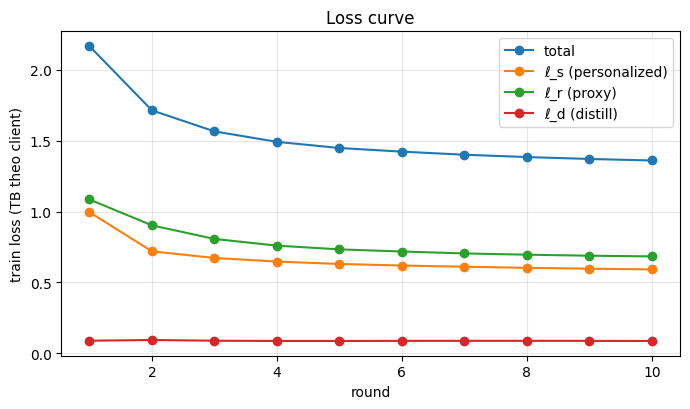

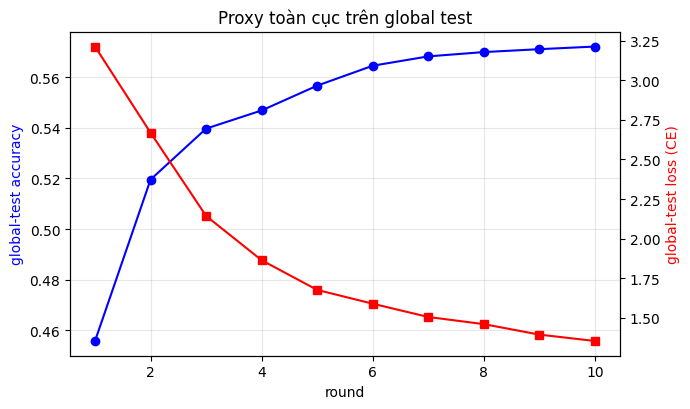

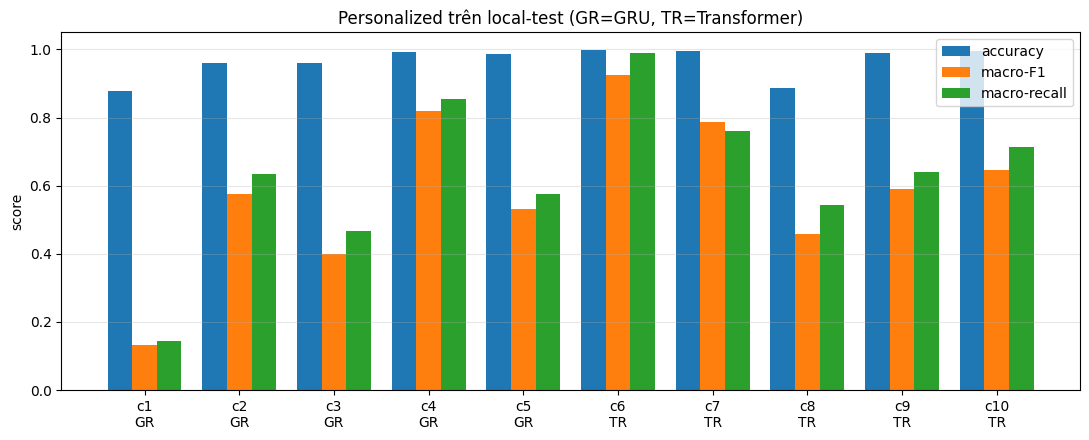

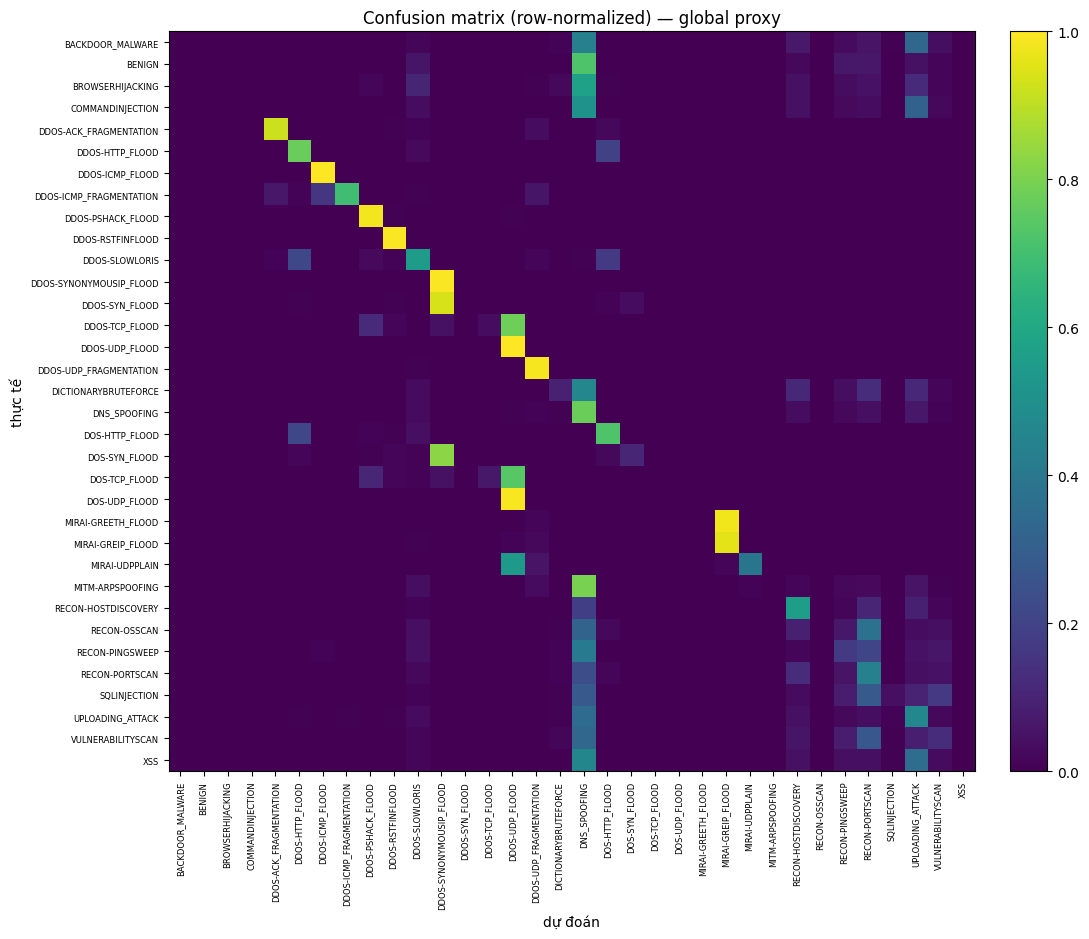

Đã lưu biểu đồ vào /kaggle/working/proxy_fml_ids/artifacts


In [22]:
import matplotlib.pyplot as plt

rounds = [h["round"] for h in history]

# (1) Loss curve theo round
plt.figure(figsize=(7, 4.2))
for key, lab in [("train_total", "total"), ("train_l_s", "ℓ_s (personalized)"),
                 ("train_l_r", "ℓ_r (proxy)"), ("train_l_d", "ℓ_d (distill)")]:
    plt.plot(rounds, [h[key] for h in history], marker="o", label=lab)
plt.xlabel("round"); plt.ylabel("train loss (TB theo client)"); plt.title("Loss curve")
plt.legend(); plt.grid(alpha=.3); plt.tight_layout()
plt.savefig(OUT / "artifacts" / "loss_curve.png", dpi=120); plt.show()

# (2) Proxy toàn cục: accuracy + loss theo round
fig, ax1 = plt.subplots(figsize=(7, 4.2))
ax1.plot(rounds, [h["proxy_global_acc"] for h in history], "b-o", label="accuracy")
ax1.set_xlabel("round"); ax1.set_ylabel("global-test accuracy", color="b"); ax1.grid(alpha=.3)
ax2 = ax1.twinx()
ax2.plot(rounds, [h["proxy_global_loss"] for h in history], "r-s", label="loss")
ax2.set_ylabel("global-test loss (CE)", color="r")
plt.title("Proxy toàn cục trên global test"); fig.tight_layout()
plt.savefig(OUT / "artifacts" / "proxy_acc_loss_curve.png", dpi=120); plt.show()

# (3) Bar chart per-client: accuracy / macro-F1 / macro-recall (màu theo họ model)
ks = sorted(per_client)
acc = [per_client[k]["accuracy"] for k in ks]
f1  = [per_client[k]["macro_f1"] for k in ks]
rec = [per_client[k]["macro_recall"] for k in ks]
x = np.arange(len(ks)); w = 0.26
plt.figure(figsize=(11, 4.5))
plt.bar(x - w, acc, w, label="accuracy")
plt.bar(x,     f1,  w, label="macro-F1")
plt.bar(x + w, rec, w, label="macro-recall")
plt.xticks(x, [f"c{k}\n{per_client[k]['model'][:2].upper()}" for k in ks])
plt.ylim(0, 1.05); plt.ylabel("score"); plt.title("Personalized trên local-test (GR=GRU, TR=Transformer)")
plt.legend(); plt.grid(axis="y", alpha=.3); plt.tight_layout()
plt.savefig(OUT / "artifacts" / "per_client_metrics.png", dpi=120); plt.show()

# (4) Confusion matrix proxy toàn cục (chuẩn hoá theo hàng)
cm = confusion_matrix(yg, pg, labels=LABELS).astype(float)
cmn = cm / cm.sum(1, keepdims=True).clip(min=1)
plt.figure(figsize=(11, 9.5))
plt.imshow(cmn, aspect="auto", cmap="viridis", vmin=0, vmax=1)
plt.colorbar(fraction=0.046, pad=0.04)
plt.xticks(range(len(LABELS)), CLASS_NAMES, rotation=90, fontsize=6)
plt.yticks(range(len(LABELS)), CLASS_NAMES, fontsize=6)
plt.xlabel("dự đoán"); plt.ylabel("thực tế")
plt.title("Confusion matrix (row-normalized) — global proxy"); plt.tight_layout()
plt.savefig(OUT / "artifacts" / "confusion_matrix.png", dpi=120); plt.show()

print("Đã lưu biểu đồ vào", OUT / "artifacts")